--- 
#### 5-2. ML실습_회귀3

- California Housing Price
--- 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

In [2]:
# sklearn 내장데이터를 df로 변환 
from sklearn.datasets import fetch_california_housing
df = fetch_california_housing(as_frame=True).frame

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# 변수타입 
df.info()
# 결측치 확인 
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

<Axes: xlabel='MedHouseVal', ylabel='Count'>

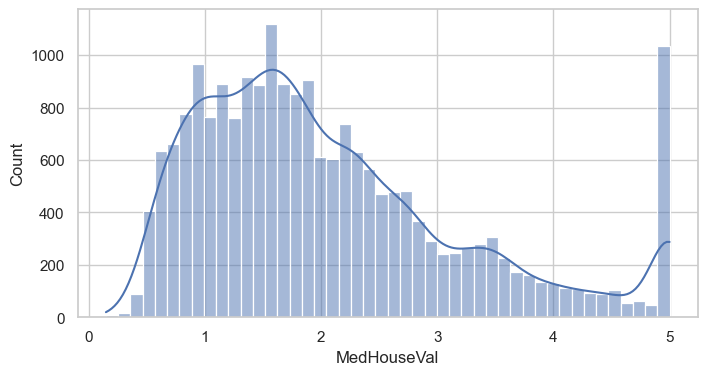

In [4]:
# 타겟 분포 
plt.figure(figsize=(8,4))
sns.histplot(df['MedHouseVal'], kde=True)

- 주택가격 조사 당시, 50만 달러 이상은 일괄 50만 달러로 입력함 

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


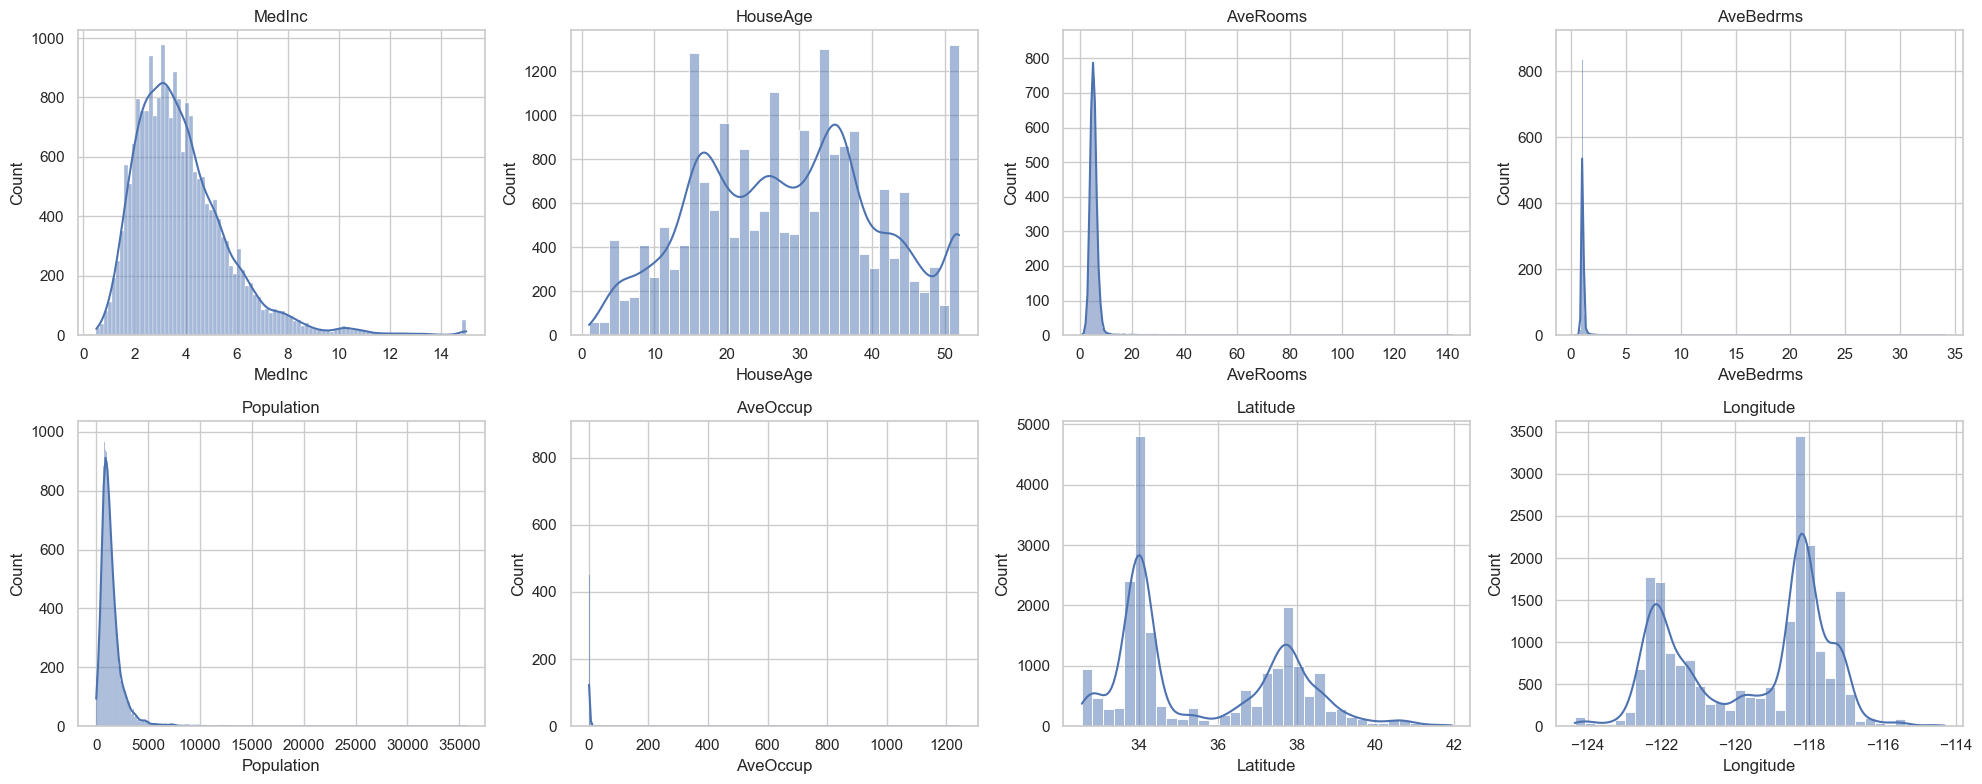

In [5]:
# 변수 분포 
cols = df.columns[:-1]
print(cols)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

k = 0
for i in range(2):
    for j in range(4):
        sns.histplot(df[cols[k]], kde=True, ax=axes[i][j])
        axes[i][j].set_title(cols[k])
        k += 1

plt.tight_layout()
plt.show()

- 결측치가 없고 모든 변수가 수치형이다. 
- 타겟변수에서 50만불 이상인 데이터의 처리방법 고민 필요 
- 입력변수들의 측정단위와 분포가 상이하다. 
---

In [6]:
# 타겟정의, 데이터 분할 
y = df['MedHouseVal']
X = df.drop('MedHouseVal', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## 선형모델을 위한 스케일링 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

#### Linear Models 

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [8]:
# 1. Linear regression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

lr_pred = model_lr.predict(X_valid_scaled)
rmse = root_mean_squared_error(y_valid, lr_pred)
r2 = r2_score(y_valid, lr_pred)

print('RMSE_Linesr = ', round(rmse,4))
print('R2_Linear = ', round(r2,4))

RMSE_Linesr =  0.7456
R2_Linear =  0.5758


In [9]:
# 2. Ridge
L2 = 10    ## 0.1, 1, 10, 100   (회귀계수 크기를 얼마나 줄일까?)

model_rg = Ridge(alpha=L2)
model_rg.fit(X_train_scaled, y_train)

rg_pred = model_rg.predict(X_valid_scaled)
rmse = root_mean_squared_error(y_valid, rg_pred)
r2 = r2_score(y_valid, rg_pred)

print('RMSE_Ridge = ', round(rmse,4))
print('R2_Ridge = ', round(r2,4))

RMSE_Ridge =  0.7453
R2_Ridge =  0.5761


In [10]:
# 3. Rasso
L1 = 0.1    ## 0.0001, 0.001, 0.01, 0.1, 1  (어디서부터 회귀계수를 없앨까?)

model_ls = Lasso(alpha=L1)
model_ls.fit(X_train_scaled, y_train)

ls_pred = model_ls.predict(X_valid_scaled)
rmse = root_mean_squared_error(y_valid, ls_pred)
r2 = r2_score(y_valid, ls_pred)

print('RMSE_Lasso = ', round(rmse,4))
print('R2_Lasso = ', round(r2,4))

RMSE_Lasso =  0.8244
R2_Lasso =  0.4814


In [11]:
# 4. Elastic Net
# Alpha는 전체 규제의 강도, l1_ration는 L1 & L2 규제의 혼합 비율을 의미한다. 

L3 = 0.1       # 0.01, 0.1, 1 
model_en = ElasticNet(alpha=L3, l1_ratio=0.5)
model_en.fit(X_train_scaled, y_train)

en_pred = model_en.predict(X_valid_scaled)
rmse = root_mean_squared_error(y_valid, en_pred)
r2 = r2_score(y_valid, en_pred)

print('RMSE_Lasso = ', round(rmse,4))
print('R2_Lasso = ', round(r2,4))

RMSE_Lasso =  0.7974
R2_Lasso =  0.5148


In [12]:
# 5. KNN 
k = 4   # 3,4,5,6,7     (최근접 k개의 평균을 낸다.)
model_knn = KNeighborsRegressor(n_neighbors=k) 
model_knn.fit(X_train_scaled, y_train)

knn_pred = model_knn.predict(X_valid_scaled)
rmse = root_mean_squared_error(y_valid, knn_pred)
r2 = r2_score(y_valid, knn_pred)

print('RMSE_KNN = ', round(rmse,4))
print('R2_KNN = ', round(r2,4))

RMSE_KNN =  0.6689
R2_KNN =  0.6586


#### Tree Models 

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [14]:
# 1. Decision Tree 
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)
dt_pred = model_dt.predict(X_valid)

rmse = root_mean_squared_error(y_valid, dt_pred)
r2 = r2_score(y_valid, dt_pred)
print('RMSE_DT = ', round(rmse,4))
print('R2_DT = ', round(r2,4))

RMSE_DT =  0.7069
R2_DT =  0.6187


In [15]:
# 2. Random forest
model_rf = RandomForestRegressor(random_state=42)    
model_rf.fit(X_train, y_train)
rf_pred = model_rf.predict(X_valid)

rmse = root_mean_squared_error(y_valid, rf_pred)
r2 = r2_score(y_valid, rf_pred)
print('RMSE_RF = ', round(rmse,4))
print('R2_RF = ', round(r2,4))

RMSE_RF =  0.5057
R2_RF =  0.8049


In [16]:
# 3. Gradient Boosting 
model_gb = GradientBoostingRegressor(random_state=42)    
model_gb.fit(X_train, y_train)
gb_pred = model_gb.predict(X_valid)

rmse = root_mean_squared_error(y_valid, gb_pred)
r2 = r2_score(y_valid, gb_pred)
print('RMSE_GB = ', round(rmse,4))
print('R2_GB = ', round(r2,4))

RMSE_GB =  0.5422
R2_GB =  0.7756


In [17]:
# 4. Gradient Boosting with tunning 
model_gb2 = GradientBoostingRegressor(
    random_state=42, 
    learning_rate = 0.05,     # 학습율 0.1 -> 0.05 (보다 더 자세히 학습)  
    n_estimators = 500,       # 반복횟수 100 -> 500 
    max_depth = 3,            # 기본값 사용 
    subsample = 0.8           # 1.0 -> 0.8 (과적합 방지위해 각 트리 학습시 데이터의 80%만 사용)
    )    


model_gb2.fit(X_train, y_train)
gb2_pred = model_gb2.predict(X_valid)

rmse = root_mean_squared_error(y_valid, gb2_pred)
r2 = r2_score(y_valid, gb2_pred)
print('RMSE_GB2 = ', round(rmse,4))
print('R2_GB2 = ', round(r2,4))

RMSE_GB2 =  0.5014
R2_GB2 =  0.8081


#### Boosting 

In [18]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [19]:
# 1. LightGBM 
model_gbm = LGBMRegressor(random_state=42, verbosity=-1)
model_gbm.fit(X_train, y_train)
gbm_pred = model_gbm.predict(X_valid)

rmse = root_mean_squared_error(y_valid, gbm_pred)
r2 = r2_score(y_valid, gbm_pred)
print('RMSE_LGBM = ', round(rmse,4))
print('R2_LGBM = ', round(r2,4))

RMSE_LGBM =  0.4635
R2_LGBM =  0.836


In [20]:
# 2. XGBoost
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)
xgb_pred = model_xgb.predict(X_valid)

rmse = root_mean_squared_error(y_valid, xgb_pred)
r2 = r2_score(y_valid, xgb_pred)
print('RMSE_XGB = ', round(rmse,4))
print('R2_XGB = ', round(r2,4))

RMSE_XGB =  0.4718
R2_XGB =  0.8301
